# Primal-Dual Hybrid Gradient (Chambolle–Pock)

For problems $\min_x f(Kx)+g(x)$, PDHG updates
$$
y^{k+1}=\operatorname{prox}_{\sigma f^\*}(y^k+\sigma K\bar x^k),\quad
x^{k+1}=\operatorname{prox}_{\tau g}(x^k-\tau K^\top y^{k+1}),
$$
with extrapolation $\bar x^{k+1}=x^{k+1}+\theta(x^{k+1}-x^k)$.
We demonstrate denoising with TV-like finite differences.

PDHG addresses saddle problems of the form
$$\min_x\max_y\;G(x)+\langle Kx,y\rangle-F^*(y)$$
with alternating proximal steps. Its stability condition $\tau\sigma\|K\|^2<1$ links step sizes to operator geometry. Objective and residual curves make convergence and instability distinguishable.


## Environment

We load numerical tools and define a notebook-local output directory for generated figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/pdhg-chambolle-pock") if Path("python/pdhg-chambolle-pock").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Numerical Experiment

We implement the core algorithm and generate comparative visuals to expose behavior clearly.


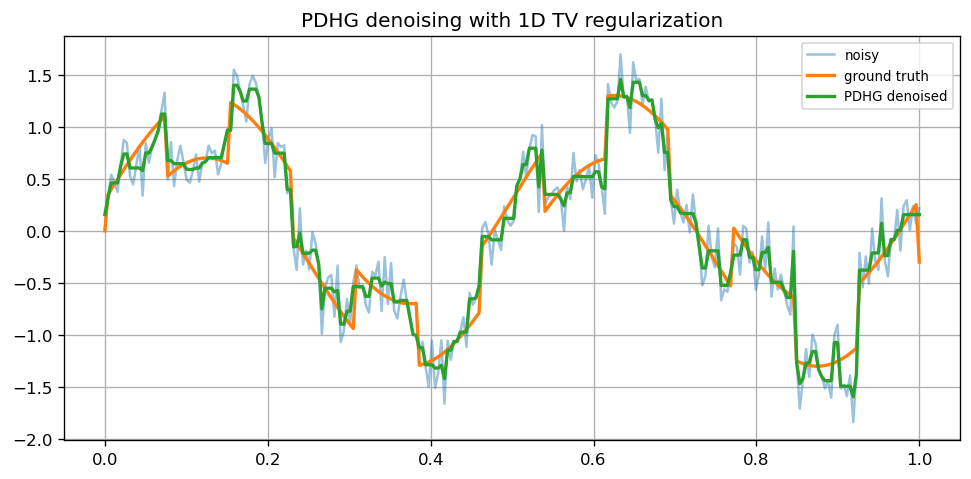

In [2]:
n = 260
xgrid = np.linspace(0,1,n)
u0 = np.sin(4*np.pi*xgrid) + 0.3*np.sign(np.sin(13*np.pi*xgrid))
rng = np.random.default_rng(0)
yobs = u0 + 0.22*rng.standard_normal(n)

lam = 0.12
tau = 0.25
sigma = 0.25
theta = 1.0

def D(u):
    return np.roll(u,-1) - u
def DT(p):
    return p - np.roll(p,1)

x = yobs.copy()
xbar = x.copy()
p = np.zeros_like(x)

for _ in range(360):
    p = p + sigma*D(xbar)
    p = p / np.maximum(1.0, np.abs(p)/lam)  # prox of indicator of |p|<=lam
    x_old = x.copy()
    x = (x + tau*(DT(p) + yobs)) / (1 + tau)  # prox for 0.5||x-y||^2
    xbar = x + theta*(x - x_old)

fig, ax = plt.subplots(figsize=(8.2,4.1))
ax.plot(xgrid, yobs, alpha=0.45, label="noisy")
ax.plot(xgrid, u0, lw=2, label="ground truth")
ax.plot(xgrid, x, lw=2, label="PDHG denoised")
ax.set_title("PDHG denoising with 1D TV regularization")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- A. Chambolle, T. Pock, "A First-Order Primal-Dual Algorithm for Convex Problems", J. Math. Imaging Vis., 2011.
- A. Chambolle, T. Pock, "An Introduction to Continuous Optimization for Imaging", Acta Numerica, 2016.
- N. Parikh, S. Boyd, "Proximal Algorithms", Foundations and Trends in Optimization, 2014.
